# Validación clínica avanzada y decisión operativa

Este notebook añade una capa de validación clínica avanzada al proyecto de predicción de cáncer. El foco no está solo en comparar métricas, sino en estudiar utilidad clínica, equidad, incertidumbre entre modelos, sensibilidad a cambios de prevalencia y valor incremental de bloques de variables.

Las figuras se guardan automáticamente en `figures/validacion_clinica/`.


## Setup reproducible

El notebook reconstruye desde `data/cancer_dataset_unido.csv` los objetos mínimos necesarios: partición train/test, preprocesado, modelo Boosting, MLP, probabilidades y umbrales optimizados en validación. Se mantienen fuera las variables post-diagnóstico o no informativas para evitar leakage y ruido.

Tras la comparación final de `modelo.ipynb`, el modelo operativo por defecto es `HistGradientBoosting` con umbral optimizado. La MLP se conserva como comparador.


In [2]:
# Setup reproducible para validación clínica avanzada
import os
from pathlib import Path

os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras

from keras import layers, regularizers
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
TARGET = "cancer"
ID_COL = "paciente_id"
FIG_DIR = Path("figures/validacion_clinica")
FIG_DIR.mkdir(parents=True, exist_ok=True)

leakage_or_postdiagnosis_features = [
    "coste_total",
    "coste_farmaco",
    "num_ingresos",
    "dias_hospital",
    "vive",
    "alcohol",
]

df_cancer = pd.read_csv("data/cancer_dataset_unido.csv")
excluded_features = [TARGET, ID_COL] + leakage_or_postdiagnosis_features
X = df_cancer.drop(columns=excluded_features)
y = df_cancer[TARGET].astype(int)

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

boosting_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.06,
    l2_regularization=0.1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
boosting_model.fit(X_train_prep, y_train)
y_test_proba_boosting = boosting_model.predict_proba(X_test_prep)[:, 1]

keras.utils.set_random_seed(RANDOM_STATE)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train,
)
class_weight = {0: float(class_weights_array[0]), 1: float(class_weights_array[1])}

def crear_modelo_mlp(input_dim):
    modelo = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.25),
        layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.25),
        layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.20),
        layers.Dense(1, activation="sigmoid"),
    ])
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return modelo

X_train_mlp_all = X_train_prep.astype("float32")
y_train_mlp_all = y_train.to_numpy().astype("float32")
X_mlp_train, X_mlp_val, y_mlp_train, y_mlp_val = train_test_split(
    X_train_mlp_all,
    y_train_mlp_all,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

mlp_model = crear_modelo_mlp(X_train_prep.shape[1])
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
    verbose=0,
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=6,
    min_lr=1e-5,
    verbose=0,
)

history_mlp = mlp_model.fit(
    X_mlp_train,
    y_mlp_train,
    validation_data=(X_mlp_val, y_mlp_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr],
    verbose=0,
)

thresholds_validacion = np.arange(0.10, 0.91, 0.01)


def evaluar_thresholds(y_true, y_proba, nombre_modelo):
    return pd.DataFrame([
        {
            "modelo": nombre_modelo,
            "threshold": threshold,
            "precision": precision_score(y_true, y_proba >= threshold, zero_division=0),
            "recall": recall_score(y_true, y_proba >= threshold, zero_division=0),
            "f1": f1_score(y_true, y_proba >= threshold, zero_division=0),
        }
        for threshold in thresholds_validacion
    ])


y_val_proba_mlp = mlp_model.predict(X_mlp_val, verbose=0).ravel()
threshold_results_mlp = evaluar_thresholds(y_mlp_val, y_val_proba_mlp, "MLP")
best_threshold_mlp = float(threshold_results_mlp.sort_values("f1", ascending=False).iloc[0]["threshold"])

boosting_para_umbral = clone(boosting_model)
boosting_para_umbral.fit(X_mlp_train, y_mlp_train.astype(int))
y_val_proba_boosting = boosting_para_umbral.predict_proba(X_mlp_val)[:, 1]
threshold_results_boosting = evaluar_thresholds(y_mlp_val.astype(int), y_val_proba_boosting, "Boosting")
threshold_boosting = float(threshold_results_boosting.sort_values("f1", ascending=False).iloc[0]["threshold"])
threshold_results = pd.concat([threshold_results_boosting, threshold_results_mlp], ignore_index=True)

y_test_proba_mlp = mlp_model.predict(X_test_prep.astype("float32"), verbose=0).ravel()
y_test_proba_operativo = y_test_proba_boosting
threshold_operativo = threshold_boosting
modelo_operativo_nombre = "Boosting"
y_test_pred_operativo = (y_test_proba_operativo >= threshold_operativo).astype(int)

def metricas_binarias(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
    }

metricas_base = pd.DataFrame([
    {"modelo": "Boosting", **metricas_binarias(y_test, y_test_proba_boosting, threshold_boosting)},
    {"modelo": "MLP", **metricas_binarias(y_test, y_test_proba_mlp, best_threshold_mlp)},
])

display(metricas_base.style.format({
    "threshold": "{:.2f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "auc": "{:.3f}",
    "accuracy": "{:.3f}",
}))
print(f"Figuras: {FIG_DIR.resolve()}")


,modelo,threshold,TP,FP,FN,TN,precision,recall,f1,auc,accuracy
0,Boosting,0.65,1161,942,768,7130,0.552,0.602,0.576,0.843,0.829
1,MLP,0.32,1210,1143,719,6929,0.514,0.627,0.565,0.837,0.814


Figuras: /Users/maria/Desktop/CASO CÁNCER/figures/validacion_clinica


## 1. Decision Curve Analysis (DCA)

La Decision Curve Analysis evalúa si un modelo aporta beneficio clínico neto frente a dos estrategias extremas: tratar a todos o no tratar a nadie. El Net Benefit penaliza falsos positivos según el umbral de decisión clínica.


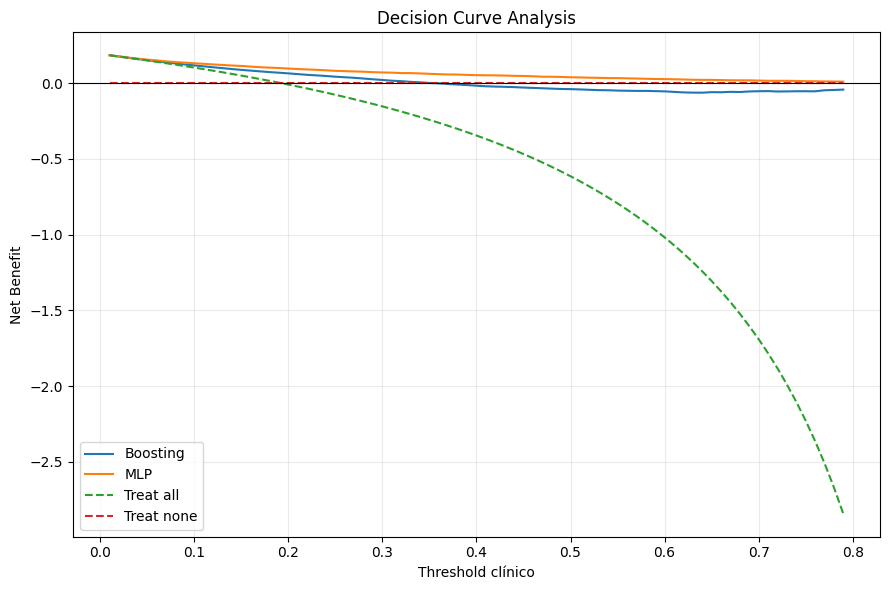

,modelo,threshold_min_beneficio,threshold_max_beneficio,n_thresholds_con_beneficio
0,MLP,0.02,0.79,78
1,Boosting,0.02,0.35,34


In [3]:
# 1. Decision Curve Analysis
thresholds_dca = np.arange(0.01, 0.80, 0.01)
y_test_array = y_test.to_numpy()
prevalencia_test = y_test_array.mean()


def net_benefit(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)
    return (tp / n) - (fp / n) * (threshold / (1 - threshold))

filas_dca = []
for threshold in thresholds_dca:
    filas_dca.extend([
        {"threshold": threshold, "estrategia": "MLP", "net_benefit": net_benefit(y_test_array, y_test_proba_mlp, threshold)},
        {"threshold": threshold, "estrategia": "Boosting", "net_benefit": net_benefit(y_test_array, y_test_proba_boosting, threshold)},
        {"threshold": threshold, "estrategia": "Treat all", "net_benefit": prevalencia_test - (1 - prevalencia_test) * (threshold / (1 - threshold))},
        {"threshold": threshold, "estrategia": "Treat none", "net_benefit": 0.0},
    ])

dca = pd.DataFrame(filas_dca)

fig, ax = plt.subplots(figsize=(9, 6))
for estrategia, df_e in dca.groupby("estrategia"):
    estilo = "--" if estrategia in ["Treat all", "Treat none"] else "-"
    ax.plot(df_e["threshold"], df_e["net_benefit"], linestyle=estilo, label=estrategia)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Decision Curve Analysis")
ax.set_xlabel("Threshold clínico")
ax.set_ylabel("Net Benefit")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(FIG_DIR / "01_decision_curve_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# Rango donde cada modelo supera simultáneamente tratar a todos y a nadie.
resumen_dca = []
for modelo in ["MLP", "Boosting"]:
    df_modelo = dca[dca["estrategia"] == modelo].set_index("threshold")
    df_all = dca[dca["estrategia"] == "Treat all"].set_index("threshold")
    ventaja = df_modelo["net_benefit"] > np.maximum(df_all["net_benefit"], 0)
    thresholds_ventaja = ventaja[ventaja].index.to_numpy()
    resumen_dca.append({
        "modelo": modelo,
        "threshold_min_beneficio": thresholds_ventaja.min() if len(thresholds_ventaja) else np.nan,
        "threshold_max_beneficio": thresholds_ventaja.max() if len(thresholds_ventaja) else np.nan,
        "n_thresholds_con_beneficio": len(thresholds_ventaja),
    })

resumen_dca = pd.DataFrame(resumen_dca)
display(resumen_dca.style.format({
    "threshold_min_beneficio": "{:.2f}",
    "threshold_max_beneficio": "{:.2f}",
}))


### Interpretación

La DCA traduce la predicción a utilidad clínica. Un modelo es útil cuando su Net Benefit queda por encima de `Treat all` y `Treat none`; ese rango de thresholds marca dónde conviene usarlo como sistema de apoyo a la decisión.


## 2. Análisis de subgrupos interseccional

La auditoría por una sola variable puede ocultar desigualdades. Aquí se cruzan dos variables sensibles disponibles, por defecto `zona × nivel_educativo`, y se comparan precision y recall por subgrupo.


Gap máximo de recall: 0.160
Gap máximo de precision: 0.159
Peor subgrupo por recall: Urbana | Primaria | recall=0.566 | n=1381


,zona,nivel_educativo,subgrupo,n,prevalencia,precision,recall,f1
8,Urbana,Primaria,Urbana | Primaria,1381,0.202,0.552,0.566,0.559
6,Semiurbana,Sin estudios,Semiurbana | Sin estudios,257,0.191,0.571,0.571,0.571
4,Semiurbana,Primaria,Semiurbana | Primaria,650,0.174,0.500,0.575,0.535
11,Urbana,Universitario,Urbana | Universitario,1346,0.194,0.561,0.582,0.571
0,Rural,Primaria,Rural | Primaria,492,0.224,0.556,0.591,0.573
3,Rural,Universitario,Rural | Universitario,497,0.213,0.589,0.594,0.592
9,Urbana,Secundaria,Urbana | Secundaria,2163,0.195,0.550,0.602,0.575
5,Semiurbana,Secundaria,Semiurbana | Secundaria,1017,0.178,0.480,0.602,0.534
2,Rural,Sin estudios,Rural | Sin estudios,218,0.170,0.639,0.622,0.630
7,Semiurbana,Universitario,Semiurbana | Universitario,645,0.186,0.556,0.625,0.588


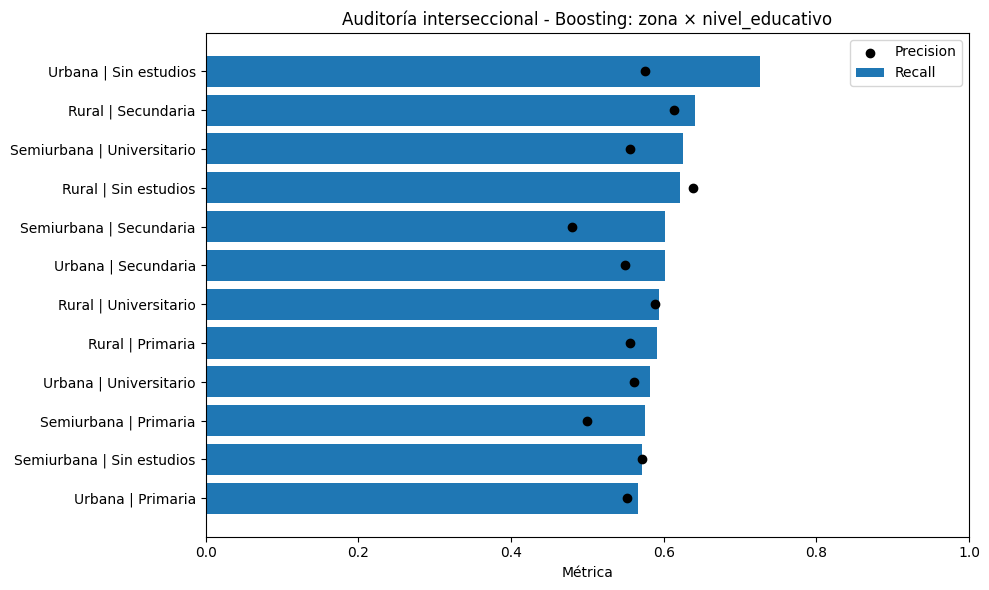

In [4]:
# 2. Auditoría interseccional de subgrupos
subgrupo_a = "zona"
subgrupo_b = "nivel_educativo"

if subgrupo_a not in X_test.columns or subgrupo_b not in X_test.columns:
    raise ValueError(f"No existen las columnas necesarias: {subgrupo_a}, {subgrupo_b}")

y_pred_operativo = y_test_pred_operativo
filas_interseccional = []

for (valor_a, valor_b), indices in X_test.groupby([subgrupo_a, subgrupo_b]).groups.items():
    idx = list(indices)
    pos = X_test.index.get_indexer(idx)
    y_true_g = y_test.loc[idx]
    y_pred_g = y_pred_operativo[pos]
    if len(y_true_g) < 30:
        continue
    filas_interseccional.append({
        subgrupo_a: valor_a,
        subgrupo_b: valor_b,
        "subgrupo": f"{valor_a} | {valor_b}",
        "n": len(y_true_g),
        "prevalencia": y_true_g.mean(),
        "precision": precision_score(y_true_g, y_pred_g, zero_division=0),
        "recall": recall_score(y_true_g, y_pred_g, zero_division=0),
        "f1": f1_score(y_true_g, y_pred_g, zero_division=0),
    })

interseccional = pd.DataFrame(filas_interseccional).sort_values("recall")
recall_gap = interseccional["recall"].max() - interseccional["recall"].min()
precision_gap = interseccional["precision"].max() - interseccional["precision"].min()
peor_recall = interseccional.iloc[0]

print(f"Gap máximo de recall: {recall_gap:.3f}")
print(f"Gap máximo de precision: {precision_gap:.3f}")
print(f"Peor subgrupo por recall: {peor_recall['subgrupo']} | recall={peor_recall['recall']:.3f} | n={int(peor_recall['n'])}")

display(interseccional.style.format({
    "prevalencia": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
}))

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = interseccional.sort_values("recall")
ax.barh(plot_df["subgrupo"], plot_df["recall"], label="Recall")
ax.scatter(plot_df["precision"], plot_df["subgrupo"], color="black", label="Precision", zorder=3)
ax.set_xlim(0, 1)
ax.set_title(f"Auditoría interseccional - {modelo_operativo_nombre}: {subgrupo_a} × {subgrupo_b}")
ax.set_xlabel("Métrica")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "02_auditoria_interseccional.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretación

El peor subgrupo por recall identifica dónde el modelo deja más casos sin detectar. Si los gaps son grandes, el rendimiento global puede estar ocultando desigualdades relevantes para uso clínico.


## 3. Intervalos de confianza para diferencias entre modelos

Además de estimar métricas individuales, se calcula la diferencia bootstrap `MLP - Boosting` para AUC y F1 usando los umbrales optimizados en validación de ambos modelos. Esto permite comprobar si la ventaja observada es robusta o compatible con cero.


,media,ci95_inf,ci95_sup,incluye_0
delta_auc_mlp_menos_boosting,-0.0064,-0.0100,-0.0030,False
delta_f1_mlp_menos_boosting,-0.0107,-0.0205,0.0009,True


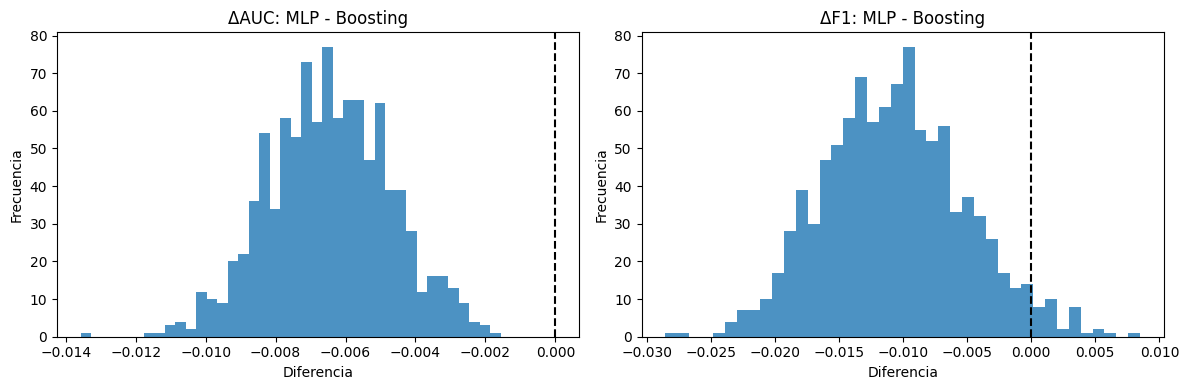

In [5]:
# 3. Bootstrap de diferencias MLP - Boosting
N_BOOTSTRAP = 1000
rng = np.random.default_rng(RANDOM_STATE)
y_true = y_test.to_numpy()

filas_delta = []
for _ in range(N_BOOTSTRAP):
    idx = rng.choice(len(y_true), size=len(y_true), replace=True)
    if len(np.unique(y_true[idx])) < 2:
        continue

    y_b = y_true[idx]
    proba_mlp_b = y_test_proba_mlp[idx]
    proba_boost_b = y_test_proba_boosting[idx]
    pred_mlp_b = (proba_mlp_b >= best_threshold_mlp).astype(int)
    pred_boost_b = (proba_boost_b >= threshold_boosting).astype(int)

    auc_mlp = roc_auc_score(y_b, proba_mlp_b)
    auc_boost = roc_auc_score(y_b, proba_boost_b)
    f1_mlp = f1_score(y_b, pred_mlp_b, zero_division=0)
    f1_boost = f1_score(y_b, pred_boost_b, zero_division=0)

    filas_delta.append({
        "delta_auc_mlp_menos_boosting": auc_mlp - auc_boost,
        "delta_f1_mlp_menos_boosting": f1_mlp - f1_boost,
    })

delta_bootstrap = pd.DataFrame(filas_delta)
resumen_delta = delta_bootstrap.agg(["mean", lambda s: np.percentile(s, 2.5), lambda s: np.percentile(s, 97.5)]).T
resumen_delta.columns = ["media", "ci95_inf", "ci95_sup"]
resumen_delta["incluye_0"] = (resumen_delta["ci95_inf"] <= 0) & (resumen_delta["ci95_sup"] >= 0)

display(resumen_delta.style.format({"media": "{:.4f}", "ci95_inf": "{:.4f}", "ci95_sup": "{:.4f}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, titulo in zip(
    axes,
    ["delta_auc_mlp_menos_boosting", "delta_f1_mlp_menos_boosting"],
    ["ΔAUC: MLP - Boosting", "ΔF1: MLP - Boosting"],
):
    ax.hist(delta_bootstrap[col], bins=40, alpha=0.8)
    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(titulo)
    ax.set_xlabel("Diferencia")
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
fig.savefig(FIG_DIR / "03_bootstrap_diferencias_modelos.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretación

Si el intervalo de confianza de `ΔF1` o `ΔAUC` incluye 0, no hay evidencia suficiente para afirmar que un modelo supera claramente al otro en esa métrica. Esto evita sacar conclusiones fuertes a partir de diferencias pequeñas.


## 4. Stress test de prevalencia

La precisión positiva depende de la prevalencia de cáncer en la población. Se simulan escenarios con prevalencia 5%, 10% y 20% manteniendo el mismo modelo operativo y el mismo threshold para ver cómo cambia el rendimiento.


,prevalencia_objetivo,prevalencia_real_media,precision_ppv_media,precision_ppv_std,recall_media,recall_std,npv_media,f1_media,n_medio
0,5%,0.050,0.213,0.006,0.602,0.022,0.977,0.315,8496
1,10%,0.100,0.364,0.005,0.601,0.012,0.952,0.453,8968
2,20%,0.200,0.563,0.001,0.602,0.000,0.899,0.582,9645


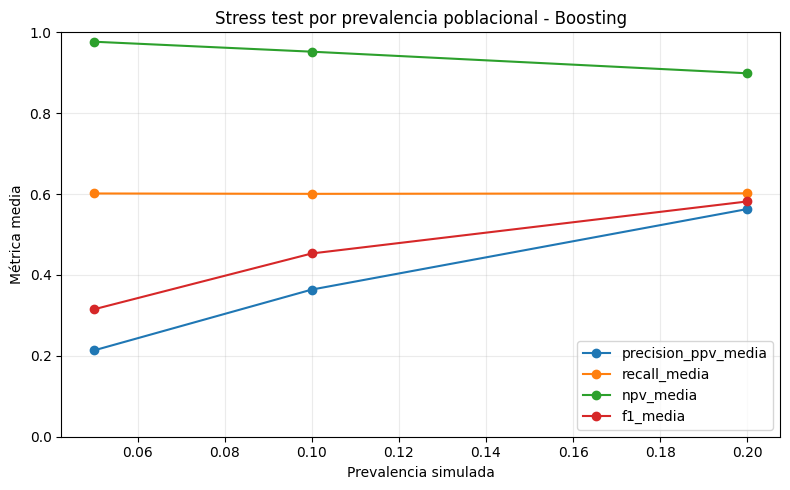

In [6]:
# 4. Stress test de prevalencia mediante submuestreo del test
prevalencias_objetivo = [0.05, 0.10, 0.20]
N_REPEATS = 200
rng = np.random.default_rng(RANDOM_STATE)

y_true = y_test.to_numpy()
pos_idx = np.where(y_true == 1)[0]
neg_idx = np.where(y_true == 0)[0]


def muestra_con_prevalencia(target_prev, rng):
    # Se usa el máximo tamaño posible respetando la prevalencia objetivo.
    n_pos_max = len(pos_idx)
    n_neg_max = len(neg_idx)
    n_total_por_pos = int(np.floor(n_pos_max / target_prev))
    n_total_por_neg = int(np.floor(n_neg_max / (1 - target_prev)))
    n_total = min(n_total_por_pos, n_total_por_neg, len(y_true))
    n_pos = max(1, int(round(n_total * target_prev)))
    n_neg = max(1, n_total - n_pos)
    idx_pos = rng.choice(pos_idx, size=n_pos, replace=False)
    idx_neg = rng.choice(neg_idx, size=n_neg, replace=False)
    return np.concatenate([idx_pos, idx_neg])

filas_shift = []
for target_prev in prevalencias_objetivo:
    for rep in range(N_REPEATS):
        idx = muestra_con_prevalencia(target_prev, rng)
        y_s = y_true[idx]
        proba_s = y_test_proba_operativo[idx]
        pred_s = (proba_s >= threshold_operativo).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_s, pred_s).ravel()
        filas_shift.append({
            "prevalencia_objetivo": target_prev,
            "prevalencia_real": y_s.mean(),
            "precision_ppv": precision_score(y_s, pred_s, zero_division=0),
            "recall_sensibilidad": recall_score(y_s, pred_s, zero_division=0),
            "npv": tn / (tn + fn) if (tn + fn) > 0 else np.nan,
            "f1": f1_score(y_s, pred_s, zero_division=0),
            "n": len(y_s),
        })

stress_prevalencia = pd.DataFrame(filas_shift)
resumen_shift = stress_prevalencia.groupby("prevalencia_objetivo").agg(
    prevalencia_real_media=("prevalencia_real", "mean"),
    precision_ppv_media=("precision_ppv", "mean"),
    precision_ppv_std=("precision_ppv", "std"),
    recall_media=("recall_sensibilidad", "mean"),
    recall_std=("recall_sensibilidad", "std"),
    npv_media=("npv", "mean"),
    f1_media=("f1", "mean"),
    n_medio=("n", "mean"),
).reset_index()

display(resumen_shift.style.format({
    "prevalencia_objetivo": "{:.0%}",
    "prevalencia_real_media": "{:.3f}",
    "precision_ppv_media": "{:.3f}",
    "precision_ppv_std": "{:.3f}",
    "recall_media": "{:.3f}",
    "recall_std": "{:.3f}",
    "npv_media": "{:.3f}",
    "f1_media": "{:.3f}",
    "n_medio": "{:.0f}",
}))

fig, ax = plt.subplots(figsize=(8, 5))
for metric in ["precision_ppv_media", "recall_media", "npv_media", "f1_media"]:
    ax.plot(resumen_shift["prevalencia_objetivo"], resumen_shift[metric], marker="o", label=metric)
ax.set_title(f"Stress test por prevalencia poblacional - {modelo_operativo_nombre}")
ax.set_xlabel("Prevalencia simulada")
ax.set_ylabel("Métrica media")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(FIG_DIR / "04_stress_test_prevalencia.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretación

Con el mismo threshold, la precision/PPV suele caer cuando la prevalencia baja, aunque el recall sea más estable. Esto muestra que una política de decisión válida en una población puede no trasladarse directamente a otra con distinta prevalencia.


## 5. Ablation study por bloques de variables

Se eliminan o restringen bloques de variables para estimar qué tipo de información aporta más valor. Este análisis ayuda a distinguir rendimiento predictivo de posibles fuentes de sesgo.


,escenario,n_variables_originales,threshold,auc,precision,recall,f1,delta_f1_vs_completo,delta_auc_vs_completo
0,Completo sin leakage,30,0.65,0.843,0.552,0.602,0.576,+0.000,+0.000
2,Sin socioeconómicas,25,0.65,0.831,0.539,0.580,0.559,-0.017,-0.012
3,Sin comorbilidades,24,0.65,0.829,0.532,0.578,0.554,-0.022,-0.014
1,Sin genéticas,23,0.65,0.774,0.487,0.463,0.475,-0.101,-0.069
4,Solo clínicas,18,0.65,0.752,0.469,0.419,0.443,-0.133,-0.091


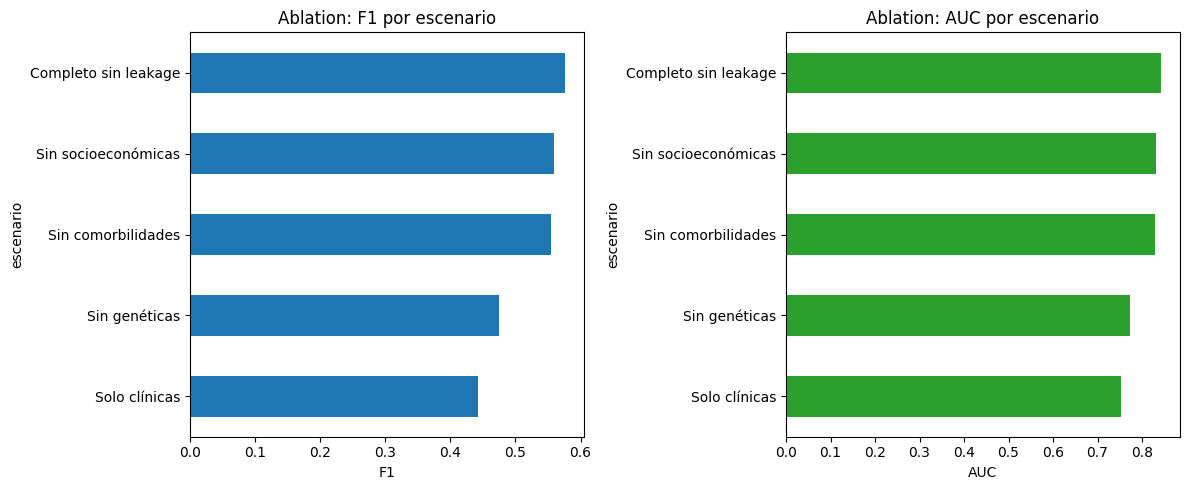

In [7]:
# 5. Ablation study rápido con Boosting
bloques_geneticos = [col for col in X.columns if col.startswith("mut_")]
bloques_socioeconomicos = [
    col for col in ["nivel_ingresos", "tipo_seguro", "nivel_educativo", "zona", "estado_civil"]
    if col in X.columns
]
comorbidity_features = [
    col for col in ["diabetes", "hipertension", "obesidad", "enfermedad_cardiaca", "asma", "epoc"]
    if col in X.columns
]
variables_clinicas = [
    col for col in X.columns
    if col not in bloques_geneticos + bloques_socioeconomicos
]

escenarios_ablation = {
    "Completo sin leakage": X.columns.tolist(),
    "Sin genéticas": [col for col in X.columns if col not in bloques_geneticos],
    "Sin socioeconómicas": [col for col in X.columns if col not in bloques_socioeconomicos],
    "Sin comorbilidades": [col for col in X.columns if col not in comorbidity_features],
    "Solo clínicas": variables_clinicas,
}

filas_ablation = []
for nombre, columnas in escenarios_ablation.items():
    X_train_a = X_train[columnas].copy()
    X_test_a = X_test[columnas].copy()

    numeric_a = X_train_a.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_a = X_train_a.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    prep_a = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_a),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_a),
        ],
        remainder="drop",
    )
    X_train_a_prep = prep_a.fit_transform(X_train_a)
    X_test_a_prep = prep_a.transform(X_test_a)

    modelo_a = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.06,
        l2_regularization=0.1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    modelo_a.fit(X_train_a_prep, y_train)
    proba_a = modelo_a.predict_proba(X_test_a_prep)[:, 1]
    pred_a = (proba_a >= threshold_boosting).astype(int)
    filas_ablation.append({
        "escenario": nombre,
        "n_variables_originales": len(columnas),
        "threshold": threshold_boosting,
        "auc": roc_auc_score(y_test, proba_a),
        "precision": precision_score(y_test, pred_a, zero_division=0),
        "recall": recall_score(y_test, pred_a, zero_division=0),
        "f1": f1_score(y_test, pred_a, zero_division=0),
    })

ablation = pd.DataFrame(filas_ablation).sort_values("f1", ascending=False)
referencia_f1 = float(ablation.loc[ablation["escenario"] == "Completo sin leakage", "f1"].iloc[0])
referencia_auc = float(ablation.loc[ablation["escenario"] == "Completo sin leakage", "auc"].iloc[0])
ablation["delta_f1_vs_completo"] = ablation["f1"] - referencia_f1
ablation["delta_auc_vs_completo"] = ablation["auc"] - referencia_auc

display(ablation.style.format({
    "threshold": "{:.2f}",
    "auc": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "delta_f1_vs_completo": "{:+.3f}",
    "delta_auc_vs_completo": "{:+.3f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ablation.sort_values("f1").plot.barh(x="escenario", y="f1", ax=axes[0], legend=False)
axes[0].set_title("Ablation: F1 por escenario")
axes[0].set_xlabel("F1")
ablation.sort_values("auc").plot.barh(x="escenario", y="auc", ax=axes[1], legend=False, color="tab:green")
axes[1].set_title("Ablation: AUC por escenario")
axes[1].set_xlabel("AUC")
plt.tight_layout()
fig.savefig(FIG_DIR / "05_ablation_study.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretación

Si al quitar un bloque apenas baja el rendimiento, ese bloque aporta poco valor predictivo. La comparación sin comorbilidades valora el posible leakage indirecto señalado en el metadata: si la caída es moderada, las comorbilidades aportan señal clínica pero no sostienen por sí solas el modelo. Si al quitar socioeconómicas baja poco, puede preferirse un modelo más prudente éticamente. Si baja mucho, conviene justificar su uso y auditar posibles desigualdades antes de desplegar.


## Implementación en entorno clínico

Esta sección traduce la validación técnica a un uso operativo realista. El objetivo no es diagnosticar automáticamente, sino priorizar pacientes para revisión médica.

La celda siguiente construye automáticamente las tablas de flujo, política de decisión, impacto por 1.000 pacientes y uso correcto del sistema.


In [8]:
# 6. Implementación en entorno clínico: tablas operativas
from sklearn.calibration import CalibratedClassifierCV

# Se usa Boosting calibrado para que los thresholds clínicos sean coherentes
# con una salida interpretable como probabilidad de riesgo.
boosting_calibrado_clinico = CalibratedClassifierCV(
    estimator=clone(boosting_model),
    method="sigmoid",
    cv=5,
    n_jobs=1,
)
boosting_calibrado_clinico.fit(X_train_prep, y_train)
y_test_proba_clinico = boosting_calibrado_clinico.predict_proba(X_test_prep)[:, 1]

filas_threshold_clinico = []
for threshold in thresholds_validacion:
    y_test_pred_tmp = (y_test_proba_clinico >= threshold).astype(int)
    filas_threshold_clinico.append(
        {
            "threshold": float(threshold),
            "precision": precision_score(y_test, y_test_pred_tmp, zero_division=0),
            "recall": recall_score(y_test, y_test_pred_tmp, zero_division=0),
            "f1": f1_score(y_test, y_test_pred_tmp, zero_division=0),
        }
    )

# Esta tabla es una simulación operativa sobre test: traduce los thresholds a carga
# hospitalaria esperada. La selección final real debería fijarse antes de test.
thresholds_clinicos = pd.DataFrame(filas_threshold_clinico)
threshold_cribado = float(
    thresholds_clinicos[thresholds_clinicos["recall"] >= 0.85]
    .sort_values("threshold", ascending=False)
    .iloc[0]["threshold"]
)
threshold_priorizacion = float(thresholds_clinicos.sort_values("f1", ascending=False).iloc[0]["threshold"])


def resumen_operativo_clinico(nombre, threshold):
    y_pred = (y_test_proba_clinico >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    escala = 1000 / len(y_test)
    return {
        "escenario": nombre,
        "threshold": threshold,
        "objetivo": "Maximizar detección" if nombre == "Cribado" else "Equilibrar detección y carga",
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "alertas_por_1000": (tp + fp) * escala,
        "casos_detectados_por_1000": tp * escala,
        "falsos_positivos_por_1000": fp * escala,
        "falsos_negativos_por_1000": fn * escala,
    }

politica_decision_clinica = pd.DataFrame(
    [
        resumen_operativo_clinico("Cribado", threshold_cribado),
        resumen_operativo_clinico("Priorización", threshold_priorizacion),
    ]
)

display(
    politica_decision_clinica.style.format(
        {
            "threshold": "{:.2f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "alertas_por_1000": "{:.0f}",
            "casos_detectados_por_1000": "{:.0f}",
            "falsos_positivos_por_1000": "{:.0f}",
            "falsos_negativos_por_1000": "{:.0f}",
        }
    )
)

flujo_operativo = pd.DataFrame(
    [
        {"paso": 1, "etapa": "Paciente", "responsable": "Sistema clínico", "salida": "Datos disponibles"},
        {"paso": 2, "etapa": "Modelo", "responsable": "IA", "salida": "Probabilidad de riesgo"},
        {"paso": 3, "etapa": "Umbral", "responsable": "Política clínica", "salida": "Alerta si riesgo supera threshold"},
        {"paso": 4, "etapa": "Revisión", "responsable": "Profesional sanitario", "salida": "Prueba confirmatoria o seguimiento"},
        {"paso": 5, "etapa": "Decisión final", "responsable": "Equipo clínico", "salida": "Decisión médica"},
    ]
)

display(flujo_operativo)

uso_correcto = pd.DataFrame(
    [
        {"tipo": "Uso recomendado", "caso": "Cribado"},
        {"tipo": "Uso recomendado", "caso": "Priorización clínica"},
        {"tipo": "Uso recomendado", "caso": "Alerta temprana"},
        {"tipo": "Uso recomendado", "caso": "Apoyo a revisión médica"},
        {"tipo": "Uso no recomendado", "caso": "Diagnóstico automático"},
        {"tipo": "Uso no recomendado", "caso": "Descarte definitivo de pacientes"},
        {"tipo": "Uso no recomendado", "caso": "Decisiones clínicas sin supervisión"},
        {"tipo": "Uso no recomendado", "caso": "Producción sin validación externa"},
    ]
)

display(uso_correcto)

limitaciones_clinicas = pd.DataFrame(
    [
        {"limitacion": "Dataset sintético", "implicacion": "Puede no reproducir completamente pacientes reales"},
        {"limitacion": "Sin validación externa", "implicacion": "Debe probarse en otra cohorte/hospital antes de uso real"},
        {"limitacion": "Disponibilidad de variables", "implicacion": "No todos los centros tendrán las mismas señales"},
        {"limitacion": "Dependencia de prevalencia", "implicacion": "PPV y carga asistencial cambian según población"},
        {"limitacion": "Variables sensibles", "implicacion": "Socioeconómicas y genéticas requieren auditoría ética"},
    ]
)

display(limitaciones_clinicas)

print(
    "Producción: el sistema requeriría monitorización continua "
    "y recalibración periódica para mantener su rendimiento."
)


,escenario,threshold,objetivo,precision,recall,f1,alertas_por_1000,casos_detectados_por_1000,falsos_positivos_por_1000,falsos_negativos_por_1000
0,Cribado,0.13,Maximizar detección,0.363,0.857,0.510,456,165,290,28
1,Priorización,0.34,Equilibrar detección y carga,0.557,0.605,0.580,210,117,93,76


,paso,etapa,responsable,salida
0,1,Paciente,Sistema clínico,Datos disponibles
1,2,Modelo,IA,Probabilidad de riesgo
2,3,Umbral,Política clínica,Alerta si riesgo supera threshold
3,4,Revisión,Profesional sanitario,Prueba confirmatoria o seguimiento
4,5,Decisión final,Equipo clínico,Decisión médica


,tipo,caso
0,Uso recomendado,Cribado
1,Uso recomendado,Priorización clínica
2,Uso recomendado,Alerta temprana
3,Uso recomendado,Apoyo a revisión médica
4,Uso no recomendado,Diagnóstico automático
5,Uso no recomendado,Descarte definitivo de pacientes
6,Uso no recomendado,Decisiones clínicas sin supervisión
7,Uso no recomendado,Producción sin validación externa


,limitacion,implicacion
0,Dataset sintético,Puede no reproducir completamente pacientes re...
1,Sin validación externa,Debe probarse en otra cohorte/hospital antes d...
2,Disponibilidad de variables,No todos los centros tendrán las mismas señales
3,Dependencia de prevalencia,PPV y carga asistencial cambian según población
4,Variables sensibles,Socioeconómicas y genéticas requieren auditorí...


Producción: el sistema requeriría monitorización continua y recalibración periódica para mantener su rendimiento.


### Interpretación operativa

El flujo propuesto es:

```text
Paciente -> datos disponibles -> cálculo de riesgo -> alerta si riesgo supera el umbral -> revisión médica -> decisión final
```

El modelo actúa como sistema de apoyo. La alerta indica prioridad de revisión, no confirmación diagnóstica.

En cribado se usa un umbral bajo para maximizar la detección. En priorización se usa un umbral más equilibrado para controlar la carga asistencial. La política final debe elegirse según recursos, prevalencia y coste clínico de falsos negativos.

El stress test de prevalencia muestra que el comportamiento cambia según el contexto poblacional: con prevalencia del 5%, el PPV medio baja a 0,213; con prevalencia del 20%, sube a 0,563. Por tanto, el modelo necesitaría validación externa, monitorización continua y recalibración periódica antes de cualquier uso en producción.
